In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [61]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2023-11-13


'2023-11-13'

In [62]:
tubulin = '[Tubulin] (' r'$\mu$' 'M)'
tub = 'tub'

DCXconc = '[DCX] (nM)' 
DCX = 'DCX'
Type = 'DCX Type'

drug = '[Drug] (' r'$\mu$' 'M)'

Concentration = 'Concentration (' r'$\mu$' 'M)'


In [63]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
darkyellow= '#FCF2B8'
yellow = '#FFCB05'
lightyellow = '#FCF2B8'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))


palette = [grey,cyan] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green]
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

StartHue3 = Color(lightyellow)
Yellowcolor = list(StartHue3.range_to(Color(darkyellow),5))
Yellowpalette = list(map(Color.get_hex,Yellowcolor))
Yellowpalette

['#fcf2b8', '#fcf2b8', '#fcf2b8', '#fcf2b8', '#fcf2b8']

In [64]:
matplotlib.rcParams['font.family'] = 'Helvetica Neue LT Std'

## Import Kappa csv ##

In [91]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [92]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if (str(i)[-4:] == 'pact') == True]
folders

[WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH1_DCX500nM_typeR178L_taxol10uM_compact'),
 WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH2_DCX500nM_typeR178L_taxol10uM_compact')]

In [93]:
files = []
for k in folders:
    files0 = [x for x in k.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('final') != -1 if str(i).rfind('csv') != -1]
    files = files + files0
files

[WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH1_DCX500nM_typeR178L_taxol10uM_compact/Stack-1-plain_Composite-final_amplified.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH1_DCX500nM_typeR178L_taxol10uM_compact/Stack-2-tax_Composite-final_amplified.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH1_DCX500nM_typeR178L_taxol10uM_compact/Stack-3-dcx_Composite-final_amplified.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH2_DCX500nM_typeR178L_taxol10uM_compact/Stack-1-plain_Composite-final_amplified.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH2_DCX500nM_typeR178L_taxol10uM_compact/Stack-2-tax_Composite-final_amplified.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_

In [94]:
files1 = [i for i in files if str(i).rfind('1-plain') != -1 ]
files2 = [i for i in files if str(i).rfind('2-tax') != -1 ]
files3 = [i for i in files if str(i).rfind('3-dcx') != -1 ]
files1

[WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH1_DCX500nM_typeR178L_taxol10uM_compact/Stack-1-plain_Composite-final_amplified.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax/CH2_DCX500nM_typeR178L_taxol10uM_compact/Stack-1-plain_Composite-final_amplified.csv')]

In [95]:
def findmetadata(tag,end,i):
    n = len(tag)
    locstart = str(i).find(tag) 
    locend = str(i).find(end, locstart)
    tag0 = str(i)[locstart+n: locend]
    
    return tag0

In [96]:
dates= []
CH= []
tax= []
dcx = []
dcxtype= []
for i in files1:
    dateloc = str(i).rfind("202")   
    dates0 = str(i)[dateloc : dateloc+10]
    dates = dates + [dates0]

    CH0 = findmetadata("CH",'_',i)
    CH = CH + [CH0]  
    
    dcx0 = findmetadata("_DCX",'nM',i)
    dcx = dcx + [float(dcx0)] 
    
    type0 = findmetadata("type",'_',i)
    dcxtype = dcxtype + [type0] 
    
    tax0 = findmetadata("taxol",'uM',i)
    tax = tax + [float(tax0)] 
    

dates,CH,dcx, dcxtype,tax

(['2023-06-22', '2023-06-22'],
 ['1', '2'],
 [500.0, 500.0],
 ['R178L', 'R178L'],
 [10.0, 10.0])

In [97]:
def keep_avg_kappa(file,i,timepoint):
    data = pd.read_csv(file, encoding='utf-8')
    
    keep_columns = ['Curve Name','Curve Length (um)']
    
    data_avg = data.drop_duplicates(subset ='Curve Length (um)', keep = 'first')
    data_avg = data_avg[keep_columns]
    
    if timepoint == 'plain':
        data_avg[drug]=0
        data_avg['Drug Type']='None'
        data_avg[DCXconc]=0
        data_avg[Type]='None'
        
    if timepoint == 'tax':
        data_avg[drug]=float(tax[i])
        data_avg['Drug Type']='Paclitaxel'
        data_avg[DCXconc]=0
        data_avg[Type]='None'
        
    if timepoint == 'dcx':
        data_avg[drug]=float(tax[i])
        data_avg['Drug Type']='Paclitaxel'
        data_avg[DCXconc]=float(dcx[i])
        data_avg[Type]=dcxtype[i]
                
        
    data_avg['Date']=dates[i]
    data_avg['CH']=CH[i]
    
    return data_avg

In [98]:
data = pd.DataFrame(columns=[] , index=[])
for i in range(0,len(files1)):
    
    data_1plain_avg = keep_avg_kappa(files1[i],i,'plain')
    data_2tax_avg = keep_avg_kappa(files2[i],i,'tax')
    data_3dcx_avg = keep_avg_kappa(files3[i],i,'dcx')

    data0 = pd.concat([data_1plain_avg, data_2tax_avg, data_3dcx_avg], ignore_index=True)

    data0 = data0.sort_values(['Curve Name',drug,DCXconc])

    data = pd.concat([data,data0], ignore_index=True)

In [99]:
data

,Curve Name,Curve Length (um),[Drug] ($\mu$M),Drug Type,[DCX] (nM),DCX Type,Date,CH
0,CURVE 1,26.532642,0.0,None,0.0,None,2023-06-22,1
1,CURVE 1,27.275833,10.0,Paclitaxel,0.0,None,2023-06-22,1
2,CURVE 1,26.617032,10.0,Paclitaxel,500.0,R178L,2023-06-22,1
3,CURVE 2,36.777001,0.0,None,0.0,None,2023-06-22,1
4,CURVE 2,37.835741,10.0,Paclitaxel,0.0,None,2023-06-22,1
5,CURVE 2,36.850689,10.0,Paclitaxel,500.0,R178L,2023-06-22,1
6,CURVE 3,37.253789,0.0,None,0.0,None,2023-06-22,1
7,CURVE 3,38.473809,10.0,Paclitaxel,0.0,None,2023-06-22,1
8,CURVE 3,37.390390,10.0,Paclitaxel,500.0,R178L,2023-06-22,1
9,CURVE 4,29.070313,0.0,None,0.0,None,2023-06-22,1


In [100]:
path.parents[1]

WindowsPath('D:/Sofia')

In [101]:
newdirectory = str(path.parents[0])+'//Compaction_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/Compaction_Data_Sheets')

In [102]:
name = dates[0]+'_'+dcxtype[0]+'_compaction_analysed-on_'+date_today +'.csv'
name

'2023-06-22_R178L_compaction_analysed-on_2023-11-13.csv'

In [103]:
data.to_csv(path/(name), encoding='utf-8', index=False)
data.to_csv(newmydir/(name), encoding='utf-8', index=False)

### JOIN ###

In [74]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [75]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if (str(i)[-3:] == 'csv') == True]
files

[WindowsPath('D:/Sofia/2022_2summer-fall/Compaction_Data_Sheets/2022-09-06_WT_compaction_analysed-on_2022-10-05.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/Compaction_Data_Sheets/2022-09-19_WT_compaction_analysed-on_2022-11-14.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/Compaction_Data_Sheets/2022-10-04_R89G_compaction_analysed-on_2022-10-05.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/Compaction_Data_Sheets/2022-10-18_R178L_compaction_analysed-on_2022-11-14.csv')]

In [76]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata.to_csv(path/('jointdata-on_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,Curve Name,Curve Length (um),[Taxol] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
0,CURVE 1,8.274138,0.0,0.0,None,2022-09-06,2
1,CURVE 1,8.496732,10.0,0.0,None,2022-09-06,2
2,CURVE 1,8.296878,10.0,125.0,WT,2022-09-06,2
3,CURVE 1,16.942064,0.0,0.0,None,2022-09-19,1
4,CURVE 1,17.233048,10.0,0.0,None,2022-09-19,1
...,...,...,...,...,...,...,...
151,CURVE 2,8.262932,10.0,0.0,None,2022-10-18,4
152,CURVE 2,8.186305,10.0,125.0,R178L,2022-10-18,4
153,CURVE 3,10.940325,0.0,0.0,None,2022-10-18,4
154,CURVE 3,11.120256,10.0,0.0,None,2022-10-18,4


## Calculate expansion ##

In [104]:
joindata = data

In [105]:
plainData = joindata.iloc[:-2:3]
taxData = joindata.iloc[1:-1:3]
dcxData = joindata.iloc[2::3]


In [106]:
def percent_expansion(beforeData, afterData):
    ratio = beforeData['Curve Length (um)'].values / afterData['Curve Length (um)'].values
    prcnt_expansion = (1- ratio)*100
    afterData['Expansion %'] = prcnt_expansion
    return afterData

In [107]:
percent_expansion(plainData, taxData)
percent_expansion(plainData, dcxData)

C:\Users\Brouhard Lab\AppData\Local\Temp\ipykernel_5356\4009520246.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  afterData['Expansion %'] = prcnt_expansion
C:\Users\Brouhard Lab\AppData\Local\Temp\ipykernel_5356\4009520246.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  afterData['Expansion %'] = prcnt_expansion


,Curve Name,Curve Length (um),[Drug] ($\mu$M),Drug Type,[DCX] (nM),DCX Type,Date,CH,Expansion %
2,CURVE 1,26.617032,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.317054
5,CURVE 2,36.850689,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.199963
8,CURVE 3,37.390390,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.365338
11,CURVE 4,29.256625,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.636818
14,CURVE 5,24.876664,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.118183
17,CURVE 1,16.394800,10.0,Paclitaxel,500.0,R178L,2023-06-22,2,-0.018447
20,CURVE 3,11.821795,10.0,Paclitaxel,500.0,R178L,2023-06-22,2,-0.023934


In [108]:
finalData = pd.concat([taxData, dcxData], ignore_index=True)
finalData = finalData.sort_values(['CH','Curve Name',drug,DCXconc])
finalData

,Curve Name,Curve Length (um),[Drug] ($\mu$M),Drug Type,[DCX] (nM),DCX Type,Date,CH,Expansion %
0,CURVE 1,27.275833,10.0,Paclitaxel,0.0,None,2023-06-22,1,2.724724
7,CURVE 1,26.617032,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.317054
1,CURVE 2,37.835741,10.0,Paclitaxel,0.0,None,2023-06-22,1,2.798253
8,CURVE 2,36.850689,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.199963
2,CURVE 3,38.473809,10.0,Paclitaxel,0.0,None,2023-06-22,1,3.171042
9,CURVE 3,37.390390,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.365338
3,CURVE 4,29.799097,10.0,Paclitaxel,0.0,None,2023-06-22,1,2.445658
10,CURVE 4,29.256625,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.636818
4,CURVE 5,25.462716,10.0,Paclitaxel,0.0,None,2023-06-22,1,2.417072
11,CURVE 5,24.876664,10.0,Paclitaxel,500.0,R178L,2023-06-22,1,0.118183


In [109]:
finalData.to_csv(path/('expansion_plain_to_tax_dcx_data-analyzed_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)

In [110]:
finalData.groupby('DCX Type').count()

,Curve Name,Curve Length (um),[Drug] ($\mu$M),Drug Type,[DCX] (nM),Date,CH,Expansion %
DCX Type,,,,,,,,
None,7,7,7,7,7,7,7,7
R178L,7,7,7,7,7,7,7,7


In [111]:
nogales2018 = (1- 81.76/83.95)*100
nogales2018

2.608695652173909

In [112]:
TAXnogales2017preformed = (1- 81.5/81.8)*100
TAXnogales2017copoly = (1- 81.5/82.3)*100
TAXnogales2017preformed , TAXnogales2017copoly


(0.3667481662591676, 0.9720534629404587)

C:\Users\Brouhard Lab\AppData\Local\Temp\ipykernel_5356\3102685061.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Type, y='Expansion %', data=finalData, whis=np.inf, palette='Blues',linewidth=3)


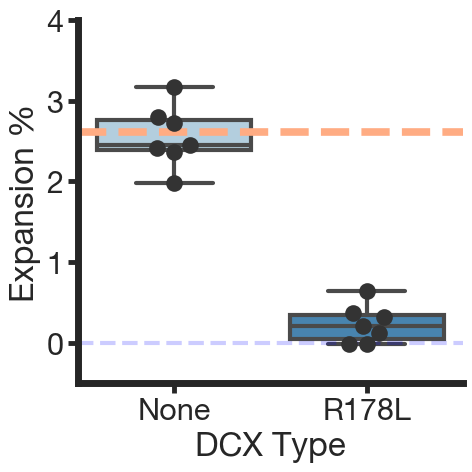

In [113]:
fig, ax = plt.subplots(1,1,figsize=(5.25,5.25))

#rect = 0,0,1,1 # create an rectangle for the new axis
#log_ax = fig.add_axes(rect) # create a new axis (or use an existing one)
#log_ax.set_xscale("log") # log first

ax = sns.boxplot(x=Type, y='Expansion %', data=finalData, whis=np.inf, palette='Blues',linewidth=3)
ax = sns.swarmplot(x=Type, y='Expansion %', data=finalData, color=".2", size=12)

ax.axhline(y = nogales2018, color = lightorange ,linestyle="--", linewidth=5.5, label='GDP'r'$\rightarrow$''GMPCPP \n Zhang (2018)')
ax.axhline(y = 0, color = 'b' ,linestyle="--", linewidth=3, alpha = 0.2)
#plt.xlim(0.1,10)

ax.set_ylim(-0.5,4)
#ax.legend( loc = 'upper right')
#ax.legend('')
#ax.set_xlabel(Type +' '+ dcx[0]+' nM')

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 3.5, length = 7)
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

sns.set_style({'font.family':'Helvetica Neue LT Std', 'font.serif':'Helvetica Neue LT Std'})

plt.tight_layout()


plt.savefig(path/('compaction_'+date_today+'.pdf'))

In [59]:
path

WindowsPath('D:/Sofia/2023_2summer-fall-DCXintensitydynmts/2023-06-22_sec-dcx_R178L-doublecap-tax')

In [86]:
(1- 81.76/83.95)*100

2.608695652173909

In [51]:
joindata

,Curve Name,Curve Length (um),[Taxol] $(\mu M)$,Date,CH
0,CURVE 1,20.464017,0.0,2022-05-03,CH2
1,CURVE 1,20.995385,10.0,2022-05-03,CH2
2,CURVE 10,19.873343,0.0,2022-05-03,CH2
3,CURVE 10,20.522329,10.0,2022-05-03,CH2
4,CURVE 2,14.120813,0.0,2022-05-03,CH2
...,...,...,...,...,...
125,CURVE 2,23.829905,0.3,2022-05-25,CH4
126,CURVE 1,14.716855,0.0,2022-05-25,CH5
127,CURVE 1,15.023748,1.0,2022-05-25,CH5
128,CURVE 2,22.356874,0.0,2022-05-25,CH5


In [52]:
joindata.groupby(taxol).size()

[Taxol] $(\mu M)$
0.0     88
0.1     12
0.3     11
1.0      9
10.0    10
dtype: int64

In [54]:
(88-12-11-9-10)/2

23.0

In [1]:
notax = 8.3301
tax = 8.5893
taxdcx = 8.3690

In [3]:
def simple_expansion(before,after):
    return (1- before/after)*100

In [4]:
simple_expansion(notax,tax)

3.0177080786560007

In [5]:
simple_expansion(notax,taxdcx)

0.4648106105866856